C:\Users\ianjw\AppData\Local\miniconda3\envs\ml\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\ianjw\AppData\Local\miniconda3\envs\ml\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


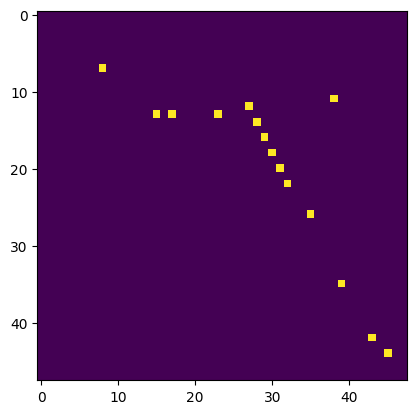

C:\Users\ianjw\AppData\Local\Temp\ipykernel_12768\2346660860.py:35: RuntimeWarning: divide by zero encountered in divide
  x /= np.std(x, axis=0, keepdims=True)
C:\Users\ianjw\AppData\Local\Temp\ipykernel_12768\2346660860.py:35: RuntimeWarning: invalid value encountered in divide
  x /= np.std(x, axis=0, keepdims=True)


((172801, 31), (172801,))

In [1]:
# Load data
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

SMOOTHING_WINDOW = 256

data = pd.read_csv("WADI_attackdataLABLE.csv") # DOWNLOAD THE DATA FROM THE LINK IN THE PAPER
# x = data[[c for c in data.columns.tolist() if c.endswith("_PV")] + ["TOTAL_CONS_REQUIRED_FLOW"]].values[:-2]
y = data["Attack LABLE (1:No Attack, -1:Attack)"].values[:-2]
req_flow = data["TOTAL_CONS_REQUIRED_FLOW"].values[:-2]

# Derive differences in redundant channels
x_a = data[[c for c in data.columns.tolist() if (c.endswith("_PV") or c.endswith("_SP")) and c[1] == "A"]].values[:-2]
x_b = data[[c for c in data.columns.tolist() if (c.endswith("_PV") or c.endswith("_SP")) and c[1] == "B"]].values[:-2]
x = np.square(x_a - x_b)

other_x = data[[c for c in data.columns.tolist() if (c.endswith("_PV") or c.endswith("_SP")) and c[1] not in ["A", "B"]] + ["TOTAL_CONS_REQUIRED_FLOW"]]
x = np.concatenate([x, other_x.values[:-2]], axis=-1)

# Remove correlated channels
x_corr = np.abs(np.corrcoef(x, rowvar=False))
np.fill_diagonal(x_corr, 0.0)
x_corr = np.triu(x_corr > 0.8)
plt.imshow(x_corr)
plt.show()

for i, j in zip(*np.nonzero(x_corr)):
    x[:, i] = np.square(x[:, i] - x[:, j])

x = x[:, [i for i in range(x.shape[1]) if i not in np.nonzero(x_corr)[1]]]

x -= np.mean(x, axis=0, keepdims=True)
x /= np.std(x, axis=0, keepdims=True)

x = x[:, np.all(np.isfinite(x), axis=0)]

for i in range(x.shape[1]):
    x[:, i] = np.convolve(x[:, i], np.ones(SMOOTHING_WINDOW)/SMOOTHING_WINDOW, mode='same')

x.shape, y.shape

In [2]:
# Separate x_fits
x_esn_fit = x[:5000]
x_rhy_fit = x[4500:5500]

In [3]:
# Find hp
from rhythmic_sharing import RhythmicNetwork

from tqdm import tqdm
import numpy as np

best_mse = np.inf

for sr in tqdm(np.linspace(0.2, 0.8, 10)):
    for iw in np.linspace(0.25, 1.0, 10):
        for l in np.linspace(0.5, 0.95, 10):
            network = RhythmicNetwork(
                # Tune Rhythmic Sharing
                dt=10,
                input_dims=x.shape[1],
                spectral_radius=sr,
                input_weight=iw,
                average_degree_nodes=8,
                num_nodes=256,
                leakage=l,
                # Rhythmic params
                link_strength_change_ratio=0
            )

            network.train(x_esn_fit.T[:, :-1000])
            pred = network.predict(x_esn_fit.T[:, -1100:], warmup_time=100)
            mse = np.mean(np.square((pred[:, 1:] - x_esn_fit.T[:, -1000:]))) # /np.std(pred[:, 1:], axis=1, keepdims=True)))
        
            if mse < best_mse:
                print("New best %.10f" % mse, (sr, iw, l))
                best_esn_param = (sr, iw, l)
                best_mse = mse

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]C:\Users\ianjw\AppData\Local\miniconda3\envs\ml\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.56703e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


New best 15379189.1122315153 (np.float64(0.2), np.float64(0.25), np.float64(0.5))


C:\Users\ianjw\AppData\Local\miniconda3\envs\ml\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.54287e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


New best 12808767.0704635344 (np.float64(0.2), np.float64(0.25), np.float64(0.55))


C:\Users\ianjw\AppData\Local\miniconda3\envs\ml\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.51023e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


...

New best 65.5715891705 (np.float64(0.6000000000000001), np.float64(1.0), np.float64(0.5))


 70%|█████████████████████████████████████████████████████▉                       | 7/10 [2:40:00<1:05:26, 1308.89s/it]C:\Users\ianjw\AppData\Local\miniconda3\envs\ml\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.92748e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


New best 61.8546705774 (np.float64(0.6666666666666667), np.float64(0.9166666666666666), np.float64(0.5))
New best 45.6891838210 (np.float64(0.6666666666666667), np.float64(1.0), np.float64(0.5))


 80%|███████████████████████████████████████████████████████████████▏               | 8/10 [3:00:52<43:01, 1290.74s/it]C:\Users\ianjw\AppData\Local\miniconda3\envs\ml\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.99558e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
 80%|███████████████████████████████████████████████████████████████▏               | 8/10 [3:17:17<49:19, 1479.69s/it]


KeyboardInterrupt: 

In [ ]:
# Find best rhymthic parameters
best_difference = 0
for lsr in np.linspace(0.25, 1, 10):
    for e1 in tqdm(np.linspace(-0.2, -0.1, 10)[::-1]):
        for o in np.linspace(0.01, 0.4, 10):
            for e2 in np.linspace(0.3, 1.0, 10):
                network = RhythmicNetwork(
                    # Tune Rhythmic Sharing
                    dt=10,
                    input_dims=x.shape[1],
                    spectral_radius=best_esn_param[0],
                    input_weight=best_esn_param[1],
                    average_degree_nodes=8,
                    num_nodes=256,
                    leakage=best_esn_param[2],
                    # Rhythmic params
                    link_strength_change_ratio=lsr,
                    omega0=o,
                    epsilon1=e1,
                    epsilon2=e2,
                )

                network.train(x_rhy_fit.T, warmup_time=0)
                r = network.get_global_parameters()[0]
    
                diff = np.abs(np.mean(r.T[100:400]) - np.mean(r.T[-400:-100]))#/np.mean(r.T[:250])
                
                if diff > best_difference and np.mean(r.T[:250]) > 0.7: # np.mean(network.get_input_parameters()[0].T[75:100, 11]) > 0.5: # and np.mean(network.get_input_parameters()[0].T[75:100, 15]) > 0.5:
                    print("New best %.10f" % diff, (lsr, e1, e2, o), np.mean(network.get_input_parameters()[0].T[175:200, 11]), np.mean(network.get_input_parameters()[0].T[225:250, 11]))
                    best_param_rhy = (lsr, e1, e2, o)
                    best_difference = diff
    
                    plt.title("Per-Input R")
                    plt.plot(network.get_input_parameters()[0].T, color="tab:blue", alpha=0.3)
                    plt.yticks([0, 0.25, 0.5, 0.75, 1])
                    plt.show()

In [4]:
best_esn_param = (0.67, 0.1, 0.5)
best_param_rhy = (0.25, -0.1, 0.45555555555555555, 0.01) # (0.25, -0.17777777777777778, 0.45555555555555555, 0.05333333333333334)

In [5]:
# Try network on data

network = RhythmicNetwork(
    # Tune Rhythmic Sharing
    dt=10,
    input_dims=x.shape[1],
    spectral_radius=best_esn_param[0],
    input_weight=best_esn_param[1],
    average_degree_nodes=8,
    num_nodes=256,
    leakage=best_esn_param[2],
    # Rhythmic params
    link_strength_change_ratio=best_param_rhy[0],
    omega0=best_param_rhy[3],
    epsilon1=best_param_rhy[1],
    epsilon2=best_param_rhy[2],
)

network.train(x.T, warmup_time=0)

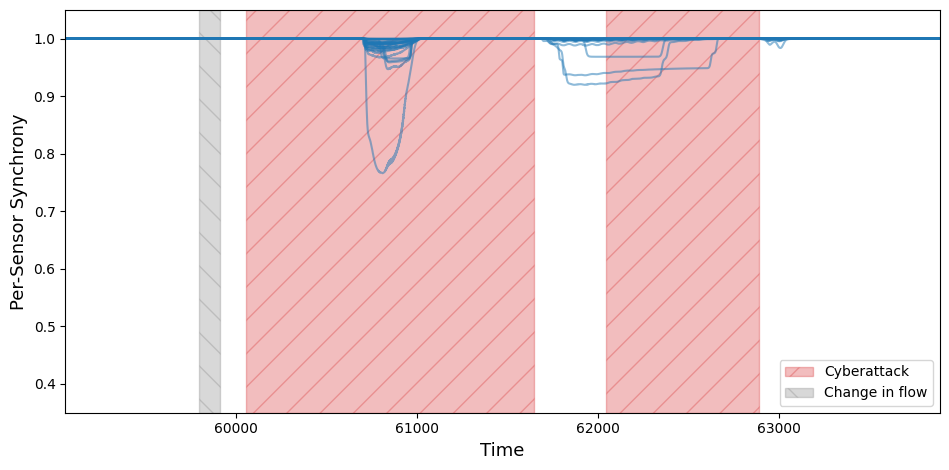

In [7]:
import matplotlib.patches as mpatches

inp_r = network.get_input_parameters()[0]

plt.figure(figsize=(6.4 * 1.5, 4.8 * 1))

SMALL_SIZE = 10
MEDIUM_SIZE = 13
BIGGER_SIZE = 20

plt.rc("font", size=SMALL_SIZE)
plt.rc("axes", titlesize=MEDIUM_SIZE, labelsize=MEDIUM_SIZE)
plt.rc("xtick", labelsize=SMALL_SIZE)
plt.rc("ytick", labelsize=SMALL_SIZE)
plt.rc("legend", fontsize=SMALL_SIZE)
plt.rc("figure", titlesize=BIGGER_SIZE)

plt.plot(inp_r.T[1000:], alpha=0.5, color="tab:blue")
plt.axvspan(60053, 60053 + 1591, color="tab:red", hatch="/", alpha=0.3)
plt.axvspan(60053 + 1990, 60053 + 2841, color="tab:red", hatch="/", alpha=0.3)
plt.axvspan(59792, 59910, color="grey", hatch="\\", alpha=0.3)

plt.xlabel("Time")
plt.ylabel("Per-Sensor Synchrony")

plt.xlim([60053 - 1000, 62893 + 1000])
plt.ylim(0.35, 1.05)

plt.legend(
    [mpatches.Patch(color="tab:red", alpha=0.3, hatch="/"), mpatches.Patch(color="grey", alpha=0.3, hatch="\\")],
    ["Cyberattack", "Change in flow"],
    loc="lower right"
)

plt.tight_layout()
plt.savefig("wadi.pdf")
plt.show()